# Blended Attack — Activation Clustering Scores Only

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone https://github.com/Aritraghoshdastidar/adaptive-backdoor-defense.git


Cloning into 'adaptive-backdoor-defense'...
remote: Enumerating objects: 130, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 130 (delta 3), reused 1 (delta 1), pack-reused 126 (from 1)
Receiving objects: 100% (130/130), 121.36 MiB | 39.69 MiB/s, done.
Resolving deltas: 100% (27/27), done.
Updating files: 100% (38/38), done.


In [3]:
# ── 0. Imports & Setup ──────────────────────────────────────────
import sys
import numpy as np
import random
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

def set_seed(seed=2025):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(2025)

sys.path.append("/content/adaptive-backdoor-defense")

from core.models import get_resnet18
from core.detection import extract_activations, run_ac, plot_ac_results

# Add the repo's specific data and attack utilities
from core.data_utils import load_cifar10, CIFARPoisoned
from core.attacks import poison_blended

In [4]:
# # ── 1. Config ───────────────────────────────────────────────────
# DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# TARGET_CLASS = 0          # airplane
# SEED         = 2025
# BATCH_SIZE   = 128

# DRIVE_ROOT   = "/content/drive/MyDrive/ps-capstone"   # ← shared Google Drive folder

# CHECKPOINTS = {
#     0.01: f"{DRIVE_ROOT}/blended_1pct.pth",
#     0.05: f"{DRIVE_ROOT}/blended_5pct.pth",
#     0.10: f"{DRIVE_ROOT}/blended_10pct.pth",
# }

# POISON_IDX_PATH = f"{DRIVE_ROOT}/blended_poison_indices.npy"
# PLOT_SAVE_DIR   = f"{DRIVE_ROOT}/ac_plots"

# import os
# os.makedirs(PLOT_SAVE_DIR, exist_ok=True)

In [5]:
# ── 1. Config ───────────────────────────────────────────────────
import torch
import os
import zipfile

DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TARGET_CLASS = 0          # airplane
SEED         = 2025
BATCH_SIZE   = 128

DRIVE_ROOT   = "/content/drive/MyDrive/ps-capstone"

# Zip file path (make sure this exists in Drive)
ZIP_PATH = f"{DRIVE_ROOT}/blended_checkpoints.zip"

# Extraction directory
EXTRACT_DIR = f"{DRIVE_ROOT}/blended_checkpoints"

# Create directory if not exists
os.makedirs(EXTRACT_DIR, exist_ok=True)

# ── 2. Unzip checkpoints (only if not already extracted) ─────────
if not os.listdir(EXTRACT_DIR):  # prevents re-unzipping every run
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Checkpoints extracted.")
else:
    print("Checkpoints already present, skipping extraction.")

# ── 3. Updated checkpoint paths ─────────────────────────────────
CHECKPOINTS = {
    0.01: f"{EXTRACT_DIR}/resnet18_blended_1pct_seed2025.pth",
    0.05: f"{EXTRACT_DIR}/resnet18_blended_5pct_seed2025.pth",
    0.10: f"{EXTRACT_DIR}/resnet18_blended_10pct_seed2025.pth",
}

# Other paths
POISON_IDX_PATH = f"{DRIVE_ROOT}/blended_poison_indices.npy"
PLOT_SAVE_DIR   = f"{DRIVE_ROOT}/ac_plots"

os.makedirs(PLOT_SAVE_DIR, exist_ok=True)

# Debug print (optional but useful)
print("Checkpoint paths:")
for k, v in CHECKPOINTS.items():
    print(f"{k}: {v}")

Checkpoints already present, skipping extraction.
Checkpoint paths:
0.01: /content/drive/MyDrive/ps-capstone/blended_checkpoints/resnet18_blended_1pct_seed2025.pth
0.05: /content/drive/MyDrive/ps-capstone/blended_checkpoints/resnet18_blended_5pct_seed2025.pth
0.1: /content/drive/MyDrive/ps-capstone/blended_checkpoints/resnet18_blended_10pct_seed2025.pth



  Blended 1% — /content/drive/MyDrive/ps-capstone/blended_checkpoints/resnet18_blended_1pct_seed2025.pth
Recreated dataset: 500 poison samples injected.
Loaded checkpoint: /content/drive/MyDrive/ps-capstone/blended_checkpoints/resnet18_blended_1pct_seed2025.pth


Extracting: 100%|██████████| 391/391 [00:13<00:00, 28.95it/s]


Target class samples:     5414
Poisoned in target class: 352


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Method:              ICA-10D
Silhouette Score:    0.0850
Cluster sizes:       [2653 2761]
Suspicious fraction: 0.4900  (49.00%)
PDR:                 12.17%
Recall:              91.76%
Saved: /content/drive/MyDrive/ps-capstone/ac_plots/ac_blended_1pct.png


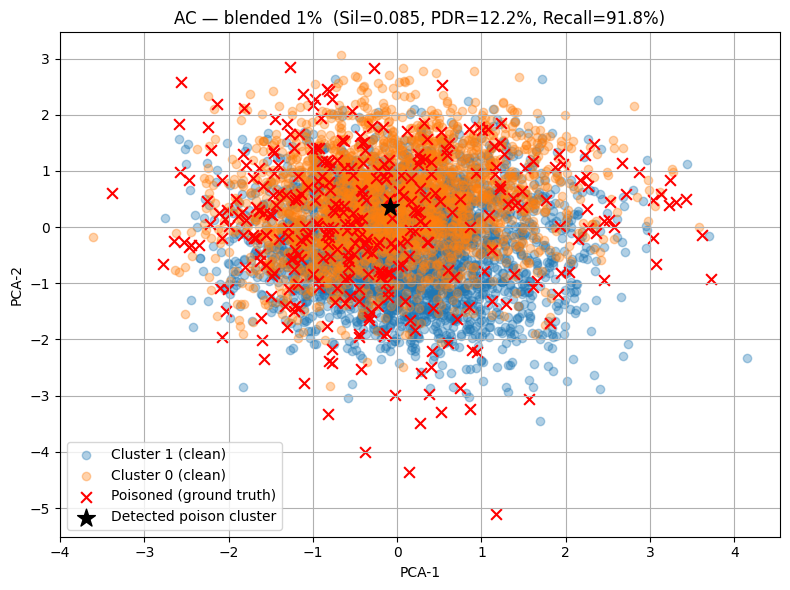


  Blended 5% — /content/drive/MyDrive/ps-capstone/blended_checkpoints/resnet18_blended_5pct_seed2025.pth
Recreated dataset: 2500 poison samples injected.
Loaded checkpoint: /content/drive/MyDrive/ps-capstone/blended_checkpoints/resnet18_blended_5pct_seed2025.pth


Extracting: 100%|██████████| 391/391 [00:13<00:00, 28.55it/s]


Target class samples:     7538
Poisoned in target class: 2357
Method:              ICA-10D
Silhouette Score:    0.1208
Cluster sizes:       [2439 5099]
Suspicious fraction: 0.3236  (32.36%)
PDR:                 93.48%
Recall:              96.73%
Saved: /content/drive/MyDrive/ps-capstone/ac_plots/ac_blended_5pct.png


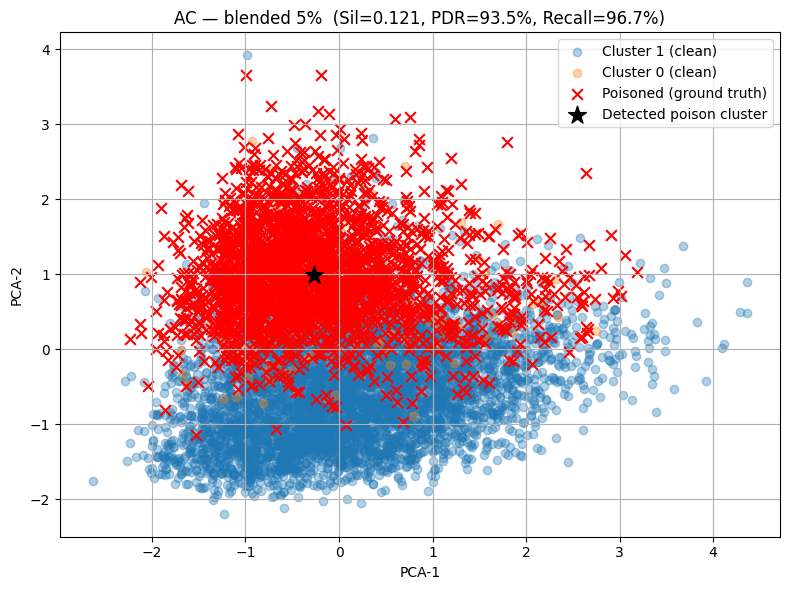


  Blended 10% — /content/drive/MyDrive/ps-capstone/blended_checkpoints/resnet18_blended_10pct_seed2025.pth
Recreated dataset: 5000 poison samples injected.
Loaded checkpoint: /content/drive/MyDrive/ps-capstone/blended_checkpoints/resnet18_blended_10pct_seed2025.pth


Extracting: 100%|██████████| 391/391 [00:13<00:00, 29.47it/s]


Target class samples:     10053
Poisoned in target class: 4810


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Method:              ICA-10D
Silhouette Score:    0.1008
Cluster sizes:       [4963 5090]
Suspicious fraction: 0.4937  (49.37%)
PDR:                 95.16%
Recall:              98.19%
Saved: /content/drive/MyDrive/ps-capstone/ac_plots/ac_blended_10pct.png


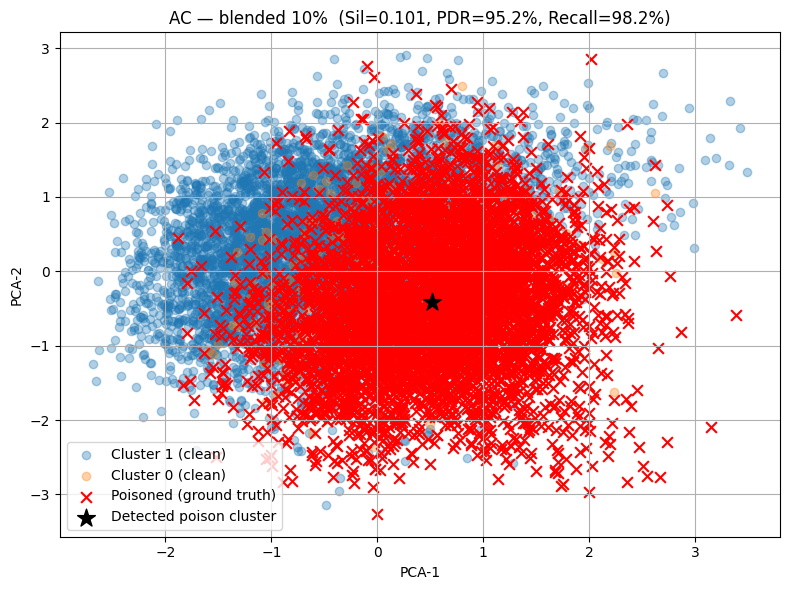

In [11]:
# ── 4. Run AC loop — scores only ────────────────────────────────
results_summary = {}

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

for poison_rate, ckpt_path in CHECKPOINTS.items():
    rate_pct = int(poison_rate * 100)
    print(f"\n{'='*55}")
    print(f"  Blended {rate_pct}% — {ckpt_path}")
    print(f"{'='*55}")

    # ── 4a. Recreate exact poisoned dataset for this rate ───────
    # Uses your repo's data_utils which saves to ./data by default
    raw_trainset = load_cifar10(train=True, transform=None)
    data = raw_trainset.data
    labels = raw_trainset.targets

    # Deterministically recreate poison_idx using the same seed
    poisoned_data, poisoned_labels, poison_idx = poison_blended(
        data=data,
        labels=labels,
        poison_rate=poison_rate,
        target_class=TARGET_CLASS,
        seed=SEED
    )

    poisoned_set = CIFARPoisoned(poisoned_data, poisoned_labels, transform=transform)
    ac_loader = DataLoader(poisoned_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    print(f"Recreated dataset: {len(poison_idx)} poison samples injected.")

    # ── 4b. Load model ──────────────────────────────────────────
    model = get_resnet18().to(DEVICE)
    ckpt  = torch.load(ckpt_path, map_location=DEVICE)

    if "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])
    elif "state_dict" in ckpt:
        model.load_state_dict(ckpt["state_dict"])
    else:
        model.load_state_dict(ckpt)

    model.eval()
    print(f"Loaded checkpoint: {ckpt_path}")

    # ── 4c. Extract activations ─────────────────────────────────
    X_all, y_pred_all, orig_idx_all = extract_activations(
        model, ac_loader, DEVICE
    )

    # ── 4d. Run AC ──────────────────────────────────────────────
    ac_results = run_ac(
        X_all, y_pred_all, orig_idx_all,
        poison_idx, target_class=TARGET_CLASS, seed=SEED
    )

    # ── 4e. Visualize ───────────────────────────────────────────
    plot_save_path = f"{PLOT_SAVE_DIR}/ac_blended_{rate_pct}pct.png"
    plot_ac_results(
        ac_results, "blended", poison_rate,
        save_path=plot_save_path
    )

    # ── 4f. Store summary ────────────────────────────────────────
    results_summary[rate_pct] = {
    "silhouette":          ac_results["silhouette"],
    "suspicious_fraction": ac_results["suspicious_fraction"],
    "PDR":                 ac_results["PDR"],
    "recall":              ac_results["recall"]
}

In [12]:
# ── 5. Summary table ─────────────────────────────────────────────
print(f"\n{'='*70}")
print("  BLENDED ATTACK — AC SCORES SUMMARY")
print(f"{'='*70}")

print(
    f"{'Rate':>6}  "
    f"{'Silhouette':>11}  "
    f"{'Susp Frac':>10}  "
    f"{'PDR':>7}  "
    f"{'Recall':>8}"
)

print("-" * 70)

for rate_pct, r in results_summary.items():
    print(
        f"{rate_pct:>5}%  "
        f"{r['silhouette']:>11.4f}  "
        f"{r['suspicious_fraction']:>10.4f}  "
        f"{r['PDR']:>6.1f}%  "
        f"{r['recall']:>7.2f}%"
    )

print("Done.")


  BLENDED ATTACK — AC SCORES SUMMARY
  Rate   Silhouette   Susp Frac      PDR    Recall
----------------------------------------------------------------------
    1%       0.0850      0.4900    12.2%    91.76%
    5%       0.1208      0.3236    93.5%    96.73%
   10%       0.1008      0.4937    95.2%    98.19%
Done.
